# Global seismicity map — one year of M5+

Map a full year of global **M5+** earthquakes from USGS, with marker area scaled by magnitude and colour by hypocentre depth — the classic view that traces the plate boundaries.

## Setup

The imports up front: `Path` for the scratch output directory, `matplotlib` for the map, and the unified `EarthLens` entry point. FDSN is a *vector* backend, so `download()` returns a `GeoDataFrame` of events.

In [1]:
from pathlib import Path

import digitalearth as de
import matplotlib.pyplot as plt
from IPython.display import Image, display

from earthlens.core import EarthLens

# Off the system drive; override with EARTHLENS_CACHE if your cache lives elsewhere.
import os

OUT_DIR = Path(os.environ.get('EARTHLENS_CACHE', 'D:/earthlens-cache')) / 'fdsn'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Query one year of global M5+ events

First build the request — source, catalogue (`variables`), the 2023 date window, a whole-globe bounding box, and a magnitude floor. Keeping construction on its own line makes the parameters easy to read and tweak.

In [2]:
quake = EarthLens(
    variables=['USGS'],
    data_source='fdsn',
    start='2023-01-01',
    end='2023-12-31',
    aoi=[-180, -90, 180, 90],
    min_magnitude=5.0,
    path=OUT_DIR,
)

The `download()` call performs the live FDSN query and returns the events into memory. It is wrapped in a `try`/`except` so the notebook degrades gracefully (rather than erroring) when run offline.

In [3]:
events = None
try:
    events = quake.download()
    print(f'{len(events)} M5+ events in 2023')
except Exception as exc:
    print(f'live FDSN query skipped (offline?): {type(exc).__name__}: {exc}')

2026-09-09 20:26:24.245 | INFO     | earthlens.fdsn.backend:_query_one:582 - Querying FDSN provider 'USGS' (USGS) for events 2023-01-01 00:00:00..2023-12-31 00:00:00 min_magnitude=5.0


2026-09-09 20:26:36.244 | INFO     | earthlens.fdsn.backend:download:728 - FDSN download summary: 1778 events across 1 file(s) written to D:\earthlens-cache\fdsn


1778 M5+ events in 2023


## Magnitude-scaled, depth-coloured scatter

Plot each epicentre with marker area growing as `2 ** magnitude` and colour set by hypocentre depth, so the deep subduction-zone events stand out from the shallow ridge seismicity. The plot is guarded on a successful download.

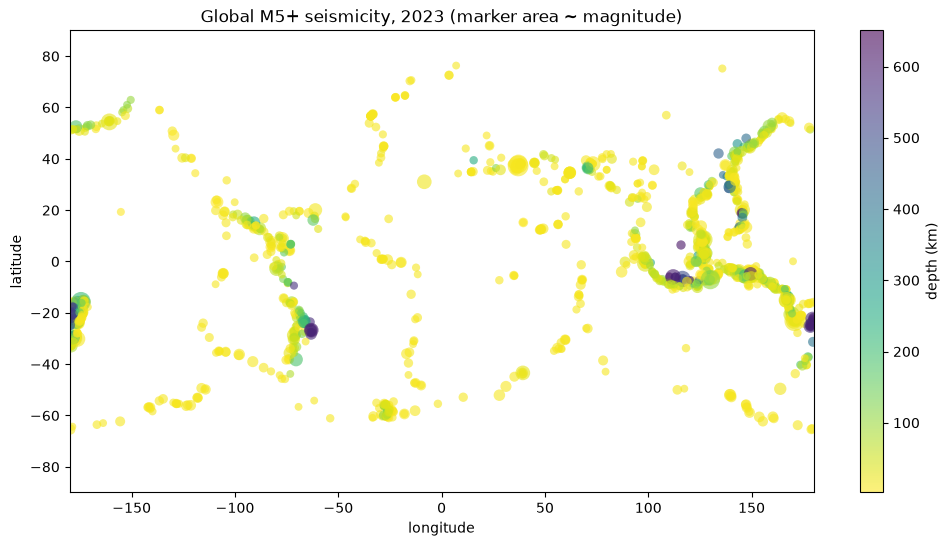

In [4]:
if events is not None and len(events):
    fig, ax = plt.subplots(figsize=(12, 6))
    sc = ax.scatter(
        events['longitude'],
        events['latitude'],
        s=2 ** events['magnitude'],
        c=events['depth_km'],
        cmap='viridis_r',
        alpha=0.6,
        edgecolor='none',
    )
    fig.colorbar(sc, ax=ax, label='depth (km)')
    ax.set_title('Global M5+ seismicity, 2023 (marker area ~ magnitude)')
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

## The same events on a globe — Digital-Earth's 3-D tier

The scatter above is drawn in raw lon/lat, so the plate boundaries it traces are stretched by the flat
projection: Alaska and the Andes end up the same width, and the ring around the Pacific is cut in half at
the antimeridian.

`digitalearth.TexturedGlobe` drapes an XYZ imagery basemap over a real sphere and scatters the epicentres
onto it, so the ring closes and the arcs keep their true shape. `from_provider` fetches the whole-world
texture once; `points` takes the `GeoDataFrame` the FDSN backend returned and culls whatever falls on the
far side, so nothing shows through the planet.

Which side faces the viewer matters more than it looks. The seismicity traces the *rim* of the Pacific,
so centring the ocean itself pushes every arc onto the limb where it foreshortens into a thin edge; the
view below is turned to the western Pacific, where half the year's events are.

This is the part of Digital-Earth that has no pyramids equivalent — pyramids plots a raster or a
`FeatureCollection` onto a 2-D axes, and stops there.

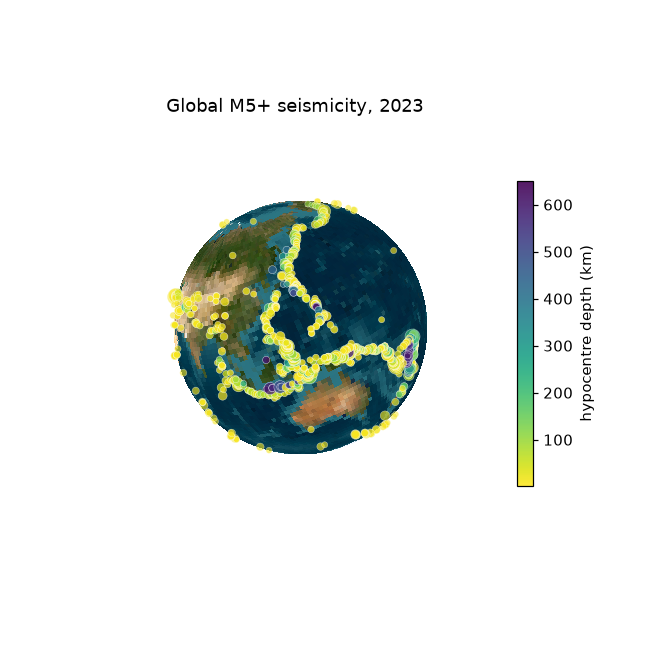

In [5]:
if events is not None and len(events):
    magnitude = events['magnitude'].to_numpy()
    depth = events['depth_km'].to_numpy()

    globe = de.TexturedGlobe.from_provider(
        'Esri.WorldImagery', texture_n_lon=1024, texture_n_lat=512, n_lon=180, n_lat=90
    )
    # The visible meridian is about 6 - spin, so 231 centres ~135E: Japan, the
    # Philippines, Indonesia and Tonga. That is where the events actually are --
    # 877 of the 1778 sit between +120 and +180. Centring the open Pacific instead
    # puts the whole ring of fire on the limb, edge-on and unreadable.
    globe.draw(spin=231.0)
    quakes = globe.points(
        events,
        s=2 ** magnitude / 2,   # marker area ~ magnitude, as in the flat map above
        c=depth,
        cmap='viridis_r',
        alpha=0.9,
        edgecolor='white',      # a hairline outline, or a deep (dark) quake vanishes into the ocean
        linewidth=0.3,
        altitude=0.02,          # lift them clear of the sphere's own facets
    )
    bar = globe.fig.colorbar(quakes, ax=globe.ax, shrink=0.6, pad=0.02)
    bar.set_label('hypocentre depth (km)')
    globe.ax.set_title('Global M5+ seismicity, 2023')
    globe.save(str(OUT_DIR / 'seismicity_globe.png'), dpi=110)
    globe.close()
    display(Image(filename=str(OUT_DIR / 'seismicity_globe.png')))

### Spinning it

`animate` turns the globe through a full revolution and `save_animation` writes it once as MP4, deriving
the GIF from that file rather than redrawing the frames. One rotation shows the whole ring of fire —
the Andes, the Aleutians, Japan, Tonga — which no single view of a sphere can.

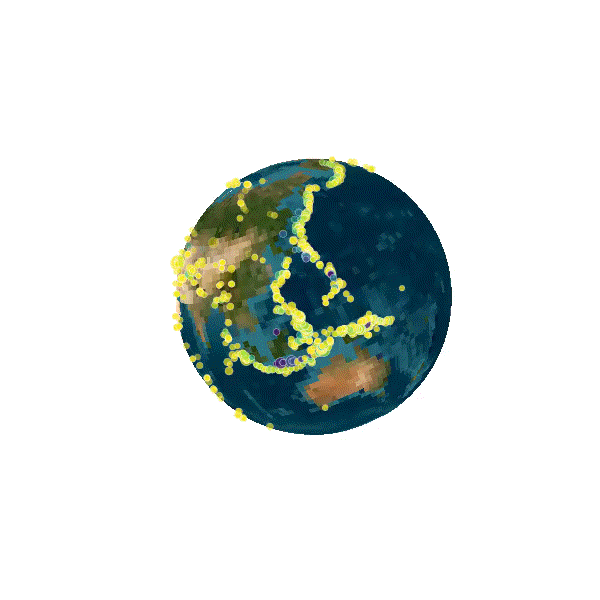

In [6]:
if events is not None and len(events):
    globe = de.TexturedGlobe.from_provider(
        'Esri.WorldImagery', texture_n_lon=768, texture_n_lat=384, n_lon=140, n_lat=70
    )
    globe.animate(n_frames=24, interval=110, figsize=(6, 6), start_spin=231.0)
    globe.points(
        events,
        s=2 ** magnitude / 2,   # marker area ~ magnitude, as in the flat map above
        c=depth,
        cmap='viridis_r',
        alpha=0.9,
        edgecolor='white',      # a hairline outline, or a deep (dark) quake vanishes into the ocean
        linewidth=0.3,
        altitude=0.02,          # lift them clear of the sphere's own facets
    )
    spin_mp4, spin_gif = globe.save_animation(
        str(OUT_DIR / 'seismicity_globe.mp4'), fps=10, gif=str(OUT_DIR / 'seismicity_globe.gif')
    )
    globe.close()
    plt.close('all')
    display(Image(filename=spin_gif))